In [1]:
pip install torch numpy pandas wfdb scikit-learn scipy


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import json
import copy
import random
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import wfdb
import torch
import torch.nn as nn
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")


# =========================================================
# CONFIG
# =========================================================
@dataclass
class Config:
    metadata_path: str = r"/Users/angga0704/VSCode/Lomba/IDSC/Misc/metadata.csv"
    files_dir: str = r"/Users/angga0704/VSCode/Lomba/IDSC/Misc/files"
    output_dir: str = "outputs_cnn_v1v3"

    random_state: int = 42

    # splits
    test_size: float = 0.20
    val_size_from_train: float = 0.20  # split from training portion

    # training
    batch_size: int = 32
    num_epochs: int = 60
    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    patience: int = 10

    # threshold tuning
    threshold_grid: Tuple[float, ...] = tuple(np.round(np.arange(0.10, 0.91, 0.01), 2))
    optimize_metric: str = "f1"   # choices: f1, balanced_accuracy, constrained_f1
    min_recall_constraint: float = 0.50

    # runtime
    num_workers: int = 0
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


CFG = Config()


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# =========================================================
# FILE UTILS
# =========================================================
def ensure_output_dirs(cfg: Config) -> Dict[str, Path]:
    base = Path(cfg.output_dir)
    paths = {
        "base": base,
        "models": base / "models",
        "metrics": base / "metrics",
        "predictions": base / "predictions",
    }
    for p in paths.values():
        p.mkdir(parents=True, exist_ok=True)
    return paths


def save_json(obj: Any, path: Path) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def save_dataframe(df: pd.DataFrame, path: Path) -> None:
    df.to_csv(path, index=False)


# =========================================================
# DATA LOADING
# =========================================================
def load_metadata(cfg: Config) -> pd.DataFrame:
    df = pd.read_csv(cfg.metadata_path)

    required = {"patient_id", "brugada"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df[df["brugada"].isin([0, 1])].copy()
    df["label"] = df["brugada"].astype(int)
    df = df.drop_duplicates(subset=["patient_id"]).reset_index(drop=True)

    return df


def load_ecg_record(patient_id: Any, files_dir: str) -> Tuple[np.ndarray, List[str], float]:
    pid = str(patient_id)
    record_path = os.path.join(files_dir, pid, pid)
    record = wfdb.rdrecord(record_path)
    return record.p_signal.astype(np.float32), list(record.sig_name), float(record.fs)


def get_v123_indices(lead_names: List[str]) -> List[int]:
    mapping = {name: idx for idx, name in enumerate(lead_names)}
    needed = ["V1", "V2", "V3"]
    idx = [mapping[name] for name in needed if name in mapping]
    if len(idx) != 3:
        raise ValueError(f"Could not find V1,V2,V3 in {lead_names}")
    return idx


def robust_normalize_per_lead(signal: np.ndarray) -> np.ndarray:
    """
    signal shape: (time, channels)
    robust normalize each lead independently
    """
    x = signal.copy()
    for c in range(x.shape[1]):
        med = np.median(x[:, c])
        mad = np.median(np.abs(x[:, c] - med)) + 1e-6
        x[:, c] = (x[:, c] - med) / mad
    return x


def build_raw_dataset(df: pd.DataFrame, cfg: Config) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    X, y, ids = [], [], []
    failed = []

    for _, row in df.iterrows():
        pid = row["patient_id"]
        label = int(row["label"])
        try:
            signal, lead_names, fs = load_ecg_record(pid, cfg.files_dir)

            # select V1-V3
            idx = get_v123_indices(lead_names)
            signal = signal[:, idx]  # shape: (1200, 3)

            # normalize
            signal = robust_normalize_per_lead(signal)

            # transpose for Conv1D => (channels, time)
            signal = signal.T.astype(np.float32)  # (3, 1200)

            X.append(signal)
            y.append(label)
            ids.append(pid)

        except Exception as e:
            failed.append((pid, str(e)))

    if failed:
        print("Failed records:", len(failed))
        print("Sample failures:", failed[:5])

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.int64)
    ids = np.asarray(ids)

    return X, y, ids


# =========================================================
# DATASET / DATALOADER
# =========================================================
class ECGDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]


# =========================================================
# MODEL
# =========================================================
class ECG1DCNN(nn.Module):
    def __init__(self, in_channels: int = 3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)


# =========================================================
# TRAINING UTILS
# =========================================================
def get_pos_weight(y_train: np.ndarray, device: str) -> torch.Tensor:
    neg = np.sum(y_train == 0)
    pos = np.sum(y_train == 1)
    pos_weight = neg / max(pos, 1)
    return torch.tensor([pos_weight], dtype=torch.float32, device=device)


def run_epoch(model, loader, criterion, optimizer, device, training=True):
    if training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    probs_all = []
    y_all = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            if training:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        probs_all.extend(probs.tolist())
        y_all.extend(y_batch.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    probs_all = np.array(probs_all)
    y_all = np.array(y_all)

    return epoch_loss, probs_all, y_all


def optimize_threshold(y_true: np.ndarray, prob: np.ndarray, cfg: Config) -> Dict[str, float]:
    best_score = -np.inf
    best = {}

    for t in cfg.threshold_grid:
        pred = (prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        bacc = balanced_accuracy_score(y_true, pred)
        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred, zero_division=0)

        if cfg.optimize_metric == "f1":
            score = f1
        elif cfg.optimize_metric == "balanced_accuracy":
            score = bacc
        elif cfg.optimize_metric == "constrained_f1":
            score = f1 if rec >= cfg.min_recall_constraint else -1e6 + rec
        else:
            raise ValueError(f"Unknown optimize_metric: {cfg.optimize_metric}")

        if score > best_score:
            best_score = score
            best = {
                "threshold": float(t),
                "f1": float(f1),
                "balanced_accuracy": float(bacc),
                "precision": float(prec),
                "recall": float(rec),
            }

    best["roc_auc"] = float(roc_auc_score(y_true, prob))
    best["pr_auc"] = float(average_precision_score(y_true, prob))
    return best


def evaluate_probs(y_true: np.ndarray, prob: np.ndarray, threshold: float) -> Dict[str, Any]:
    pred = (prob >= threshold).astype(int)

    return {
        "threshold": float(threshold),
        "roc_auc": float(roc_auc_score(y_true, prob)),
        "pr_auc": float(average_precision_score(y_true, prob)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(y_true, pred).tolist(),
        "classification_report": classification_report(y_true, pred, zero_division=0, output_dict=True),
        "predictions": pred.tolist(),
        "probabilities": prob.tolist(),
    }


# =========================================================
# MAIN
# =========================================================
def main():
    set_seed(CFG.random_state)
    output_paths = ensure_output_dirs(CFG)
    save_json(asdict(CFG), output_paths["base"] / "config.json")

    print("=" * 80)
    print("LOADING METADATA")
    print("=" * 80)
    df = load_metadata(CFG)
    print(df["label"].value_counts().sort_index())
    print("Total samples:", len(df))
    print()

    print("=" * 80)
    print("BUILDING RAW V1-V3 DATASET")
    print("=" * 80)
    X, y, ids = build_raw_dataset(df, CFG)
    print("X shape:", X.shape)   # expected: (N, 3, 1200)
    print("y shape:", y.shape)
    print()

    # train/test split
    X_train_full, X_test, y_train_full, y_test, ids_train_full, ids_test = train_test_split(
        X, y, ids,
        test_size=CFG.test_size,
        stratify=y,
        random_state=CFG.random_state,
    )

    # train/val split from training portion
    X_train, X_val, y_train, y_val, ids_train, ids_val = train_test_split(
        X_train_full, y_train_full, ids_train_full,
        test_size=CFG.val_size_from_train,
        stratify=y_train_full,
        random_state=CFG.random_state,
    )

    print("=" * 80)
    print("DATA SPLIT")
    print("=" * 80)
    print(f"Train: {X_train.shape}, positives: {int(y_train.sum())}/{len(y_train)}")
    print(f"Val  : {X_val.shape}, positives: {int(y_val.sum())}/{len(y_val)}")
    print(f"Test : {X_test.shape}, positives: {int(y_test.sum())}/{len(y_test)}")
    print()

    # datasets
    train_ds = ECGDataset(X_train, y_train)
    val_ds = ECGDataset(X_val, y_val)
    test_ds = ECGDataset(X_test, y_test)

    train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True, num_workers=CFG.num_workers)
    val_loader = DataLoader(val_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers)
    test_loader = DataLoader(test_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers)

    # model
    device = CFG.device
    model = ECG1DCNN(in_channels=3).to(device)

    pos_weight = get_pos_weight(y_train, device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=CFG.learning_rate, weight_decay=CFG.weight_decay)

    print("=" * 80)
    print("TRAINING")
    print("=" * 80)
    print("Device:", device)
    print("Pos weight:", pos_weight.item())
    print()

    best_state = None
    best_val_loss = np.inf
    patience_counter = 0
    history = []

    for epoch in range(1, CFG.num_epochs + 1):
        train_loss, train_prob, train_true = run_epoch(model, train_loader, criterion, optimizer, device, training=True)
        val_loss, val_prob, val_true = run_epoch(model, val_loader, criterion, optimizer, device, training=False)

        # validation threshold tuning
        val_thresh_metrics = optimize_threshold(val_true, val_prob, CFG)

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_roc_auc": roc_auc_score(val_true, val_prob),
            "val_f1_best_threshold": val_thresh_metrics["f1"],
            "val_recall_best_threshold": val_thresh_metrics["recall"],
            "val_threshold": val_thresh_metrics["threshold"],
        }
        history.append(row)

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val AUC: {row['val_roc_auc']:.4f} | "
            f"Val F1*: {row['val_f1_best_threshold']:.4f} | "
            f"Val Recall*: {row['val_recall_best_threshold']:.4f} | "
            f"Thr*: {row['val_threshold']:.2f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= CFG.patience:
            print(f"\nEarly stopping triggered at epoch {epoch}.")
            break

    # save history
    history_df = pd.DataFrame(history)
    save_dataframe(history_df, output_paths["metrics"] / "training_history.csv")

    # load best model
    model.load_state_dict(best_state)
    torch.save(model.state_dict(), output_paths["models"] / "best_cnn_v1v3.pt")

    print("\n" + "=" * 80)
    print("VALIDATION THRESHOLD SELECTION (BEST MODEL)")
    print("=" * 80)

    _, val_prob, val_true = run_epoch(model, val_loader, criterion, optimizer, device, training=False)
    best_val_threshold_metrics = optimize_threshold(val_true, val_prob, CFG)
    best_threshold = best_val_threshold_metrics["threshold"]

    print(json.dumps(best_val_threshold_metrics, indent=2))

    print("\n" + "=" * 80)
    print("TEST EVALUATION")
    print("=" * 80)

    _, test_prob, test_true = run_epoch(model, test_loader, criterion, optimizer, device, training=False)
    test_metrics = evaluate_probs(test_true, test_prob, best_threshold)

    print(json.dumps({
        "threshold": test_metrics["threshold"],
        "roc_auc": test_metrics["roc_auc"],
        "pr_auc": test_metrics["pr_auc"],
        "f1": test_metrics["f1"],
        "balanced_accuracy": test_metrics["balanced_accuracy"],
        "precision": test_metrics["precision"],
        "recall": test_metrics["recall"],
        "confusion_matrix": test_metrics["confusion_matrix"],
    }, indent=2))

    # save metrics
    save_json(best_val_threshold_metrics, output_paths["metrics"] / "best_val_threshold_metrics.json")
    save_json(test_metrics, output_paths["metrics"] / "test_metrics.json")

    # save test predictions
    pred_df = pd.DataFrame({
        "patient_id": ids_test,
        "y_true": y_test,
        "prob": test_prob,
        "pred": (test_prob >= best_threshold).astype(int),
    })
    save_dataframe(pred_df, output_paths["predictions"] / "test_predictions.csv")

    print("\nSaved outputs to:", output_paths["base"].resolve())


if __name__ == "__main__":
    main()

LOADING METADATA
label
0    287
1     69
Name: count, dtype: int64
Total samples: 356

BUILDING RAW V1-V3 DATASET
X shape: (356, 3, 1200)
y shape: (356,)

DATA SPLIT
Train: (227, 3, 1200), positives: 44/227
Val  : (57, 3, 1200), positives: 11/57
Test : (72, 3, 1200), positives: 14/72

TRAINING
Device: cpu
Pos weight: 4.159090995788574

Epoch 001 | Train Loss: 1.1106 | Val Loss: 1.1002 | Val AUC: 0.6680 | Val F1*: 0.4000 | Val Recall*: 0.2727 | Thr*: 0.52
Epoch 002 | Train Loss: 1.0569 | Val Loss: 1.0933 | Val AUC: 0.6364 | Val F1*: 0.4167 | Val Recall*: 0.9091 | Thr*: 0.50
Epoch 003 | Train Loss: 0.9099 | Val Loss: 1.0304 | Val AUC: 0.7213 | Val F1*: 0.5185 | Val Recall*: 0.6364 | Thr*: 0.48
Epoch 004 | Train Loss: 0.8324 | Val Loss: 0.9798 | Val AUC: 0.7569 | Val F1*: 0.5333 | Val Recall*: 0.7273 | Thr*: 0.49
Epoch 005 | Train Loss: 0.7419 | Val Loss: 0.9166 | Val AUC: 0.8241 | Val F1*: 0.6000 | Val Recall*: 0.8182 | Thr*: 0.37
Epoch 006 | Train Loss: 0.6654 | Val Loss: 1.0998 | Val A

In [ ]:
[54,4]
[6,8]

Overfit Analysis

LOADING METADATA
label
0    287
1     69
Name: count, dtype: int64
Total samples: 356

BUILDING RAW V1-V3 DATASET
X shape: (356, 3, 1200)
y shape: (356,)


RUNNING SEED 42
Train: (227, 3, 1200), positives: 44/227
Val  : (57, 3, 1200), positives: 11/57
Test : (72, 3, 1200), positives: 14/72
Device: cpu
Pos weight: 4.159090995788574
Epoch 001 | LR 0.000800 | TrainLoss 1.1031 | ValLoss 1.1058 | TrainAUC 0.6516 | ValAUC 0.6719 | TrainF1* 0.3822 | ValF1* 0.3750 | ValRec* 0.5455 | Thr* 0.51
Epoch 002 | LR 0.000800 | TrainLoss 1.0530 | ValLoss 1.1017 | TrainAUC 0.7581 | ValAUC 0.6166 | TrainF1* 0.4800 | ValF1* 0.3571 | ValRec* 0.9091 | Thr* 0.50
Epoch 003 | LR 0.000800 | TrainLoss 0.9436 | ValLoss 1.0476 | TrainAUC 0.8527 | ValAUC 0.7134 | TrainF1* 0.5806 | ValF1* 0.5185 | ValRec* 0.6364 | Thr* 0.49
Epoch 004 | LR 0.000800 | TrainLoss 0.8708 | ValLoss 1.0161 | TrainAUC 0.8479 | ValAUC 0.7075 | TrainF1* 0.5854 | ValF1* 0.4848 | ValRec* 0.7273 | Thr* 0.49
Epoch 005 | LR 0.000800 | TrainLoss 0.7

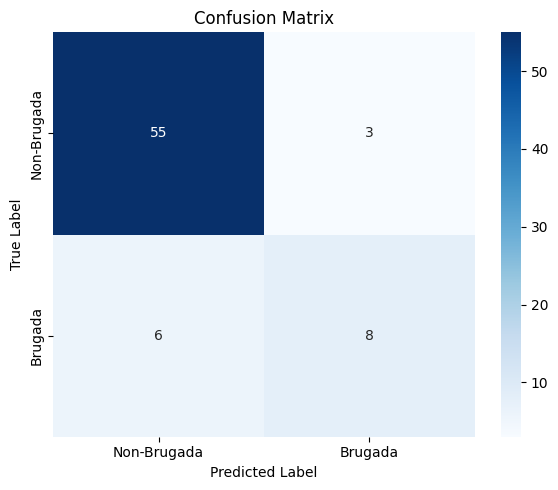


Validation threshold selection:
{
  "threshold": 0.51,
  "f1": 0.8695652173913043,
  "balanced_accuracy": 0.9328063241106719,
  "precision": 0.8333333333333334,
  "recall": 0.9090909090909091,
  "roc_auc": 0.9644268774703557,
  "pr_auc": 0.8482618391709301
}

Test evaluation:
{
  "threshold": 0.51,
  "roc_auc": 0.8620689655172413,
  "pr_auc": 0.7164593515525193,
  "f1": 0.64,
  "balanced_accuracy": 0.7598522167487685,
  "precision": 0.7272727272727273,
  "recall": 0.5714285714285714,
  "confusion_matrix": [
    [
      55,
      3
    ],
    [
      6,
      8
    ]
  ]
}

Overfitting analysis:
{
  "gap_metrics": {
    "gap_train_val_auc": 0.02240869133242618,
    "gap_val_test_auc": 0.10235791195311439,
    "gap_train_val_f1": 0.005434782608695676,
    "gap_val_test_f1": 0.2295652173913043,
    "gap_train_val_recall": 0.045454545454545525,
    "gap_val_test_recall": 0.33766233766233766
  },
  "overfitting_risk_level": "moderate",
  "overfitting_flags": [
    "val_test_auc_gap_high",


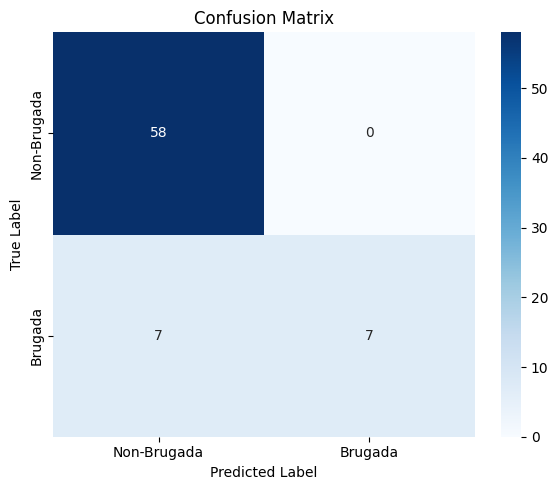


Validation threshold selection:
{
  "threshold": 0.48,
  "f1": 0.8571428571428571,
  "balanced_accuracy": 0.8982213438735178,
  "precision": 0.9,
  "recall": 0.8181818181818182,
  "roc_auc": 0.9209486166007905,
  "pr_auc": 0.8286165223665224
}

Test evaluation:
{
  "threshold": 0.48,
  "roc_auc": 0.853448275862069,
  "pr_auc": 0.7936352687750043,
  "f1": 0.6666666666666666,
  "balanced_accuracy": 0.75,
  "precision": 1.0,
  "recall": 0.5,
  "confusion_matrix": [
    [
      58,
      0
    ],
    [
      7,
      7
    ]
  ]
}

Overfitting analysis:
{
  "gap_metrics": {
    "gap_train_val_auc": 0.07495302274347171,
    "gap_val_test_auc": 0.06750034073872158,
    "gap_train_val_f1": 0.07619047619047625,
    "gap_val_test_f1": 0.19047619047619047,
    "gap_train_val_recall": 0.13636363636363635,
    "gap_val_test_recall": 0.31818181818181823
  },
  "overfitting_risk_level": "mild",
  "overfitting_flags": [
    "val_test_f1_gap_high",
    "val_test_recall_gap_high"
  ]
}

RUNNING SEED 2

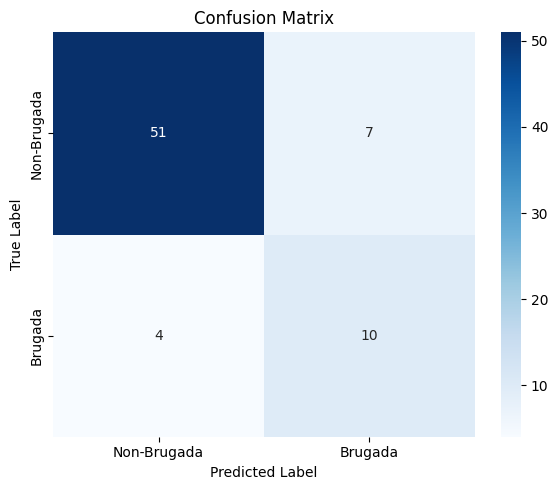


Validation threshold selection:
{
  "threshold": 0.42,
  "f1": 0.6086956521739131,
  "balanced_accuracy": 0.7638339920948616,
  "precision": 0.5833333333333334,
  "recall": 0.6363636363636364,
  "roc_auc": 0.8458498023715415,
  "pr_auc": 0.66369712243214
}

Test evaluation:
{
  "threshold": 0.42,
  "roc_auc": 0.8571428571428572,
  "pr_auc": 0.7334263625423665,
  "f1": 0.6451612903225806,
  "balanced_accuracy": 0.7967980295566502,
  "precision": 0.5882352941176471,
  "recall": 0.7142857142857143,
  "confusion_matrix": [
    [
      51,
      7
    ],
    [
      4,
      10
    ]
  ]
}

Overfitting analysis:
{
  "gap_metrics": {
    "gap_train_val_auc": 0.0461025076135555,
    "gap_val_test_auc": -0.011293054771315703,
    "gap_train_val_f1": 0.09718670076726343,
    "gap_val_test_f1": -0.036465638148667545,
    "gap_train_val_recall": 0.045454545454545414,
    "gap_val_test_recall": -0.07792207792207795
  },
  "overfitting_risk_level": "low",
  "overfitting_flags": []
}

MULTI-SEED SU

In [11]:
import os
import json
import copy
import random
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import wfdb
import torch
import torch.nn as nn
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")


# =========================================================
# CONFIG
# =========================================================
@dataclass
class Config:
    metadata_path: str = r"/Users/angga0704/Downloads/Lomba/IDSC/Dataset/Misc/metadata.csv"
    files_dir: str = r"/Users/angga0704/Downloads/Lomba/IDSC/Dataset/Misc/files"
    output_dir: str = "outputs_cnn_v1v3_round2"

    # reproducibility / robustness
    seeds: Tuple[int, ...] = (42, 123, 2026)

    # splitting
    test_size: float = 0.20
    val_size_from_train: float = 0.20

    # training
    batch_size: int = 32
    num_epochs: int = 80
    learning_rate: float = 8e-4
    weight_decay: float = 1e-4
    patience: int = 12

    # threshold tuning
    threshold_grid: Tuple[float, ...] = tuple(np.round(np.arange(0.10, 0.91, 0.01), 2))
    optimize_metric: str = "constrained_f1"   # f1, balanced_accuracy, constrained_f1
    min_recall_constraint: float = 0.50

    # scheduler
    scheduler_factor: float = 0.5
    scheduler_patience: int = 4
    scheduler_min_lr: float = 1e-6

    # runtime
    num_workers: int = 0
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


CFG = Config()


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# =========================================================
# FILE UTILS
# =========================================================
def ensure_output_dirs(cfg: Config) -> Dict[str, Path]:
    base = Path(cfg.output_dir)
    paths = {
        "base": base,
        "models": base / "models",
        "metrics": base / "metrics",
        "predictions": base / "predictions",
    }
    for p in paths.values():
        p.mkdir(parents=True, exist_ok=True)
    return paths


def save_json(obj: Any, path: Path) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def save_dataframe(df: pd.DataFrame, path: Path) -> None:
    df.to_csv(path, index=False)


# =========================================================
# DATA LOADING
# =========================================================
def load_metadata(cfg: Config) -> pd.DataFrame:
    df = pd.read_csv(cfg.metadata_path)

    required = {"patient_id", "brugada"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df[df["brugada"].isin([0, 1])].copy()
    df["label"] = df["brugada"].astype(int)
    df = df.drop_duplicates(subset=["patient_id"]).reset_index(drop=True)

    return df


def load_ecg_record(patient_id: Any, files_dir: str) -> Tuple[np.ndarray, List[str], float]:
    pid = str(patient_id)
    record_path = os.path.join(files_dir, pid, pid)
    record = wfdb.rdrecord(record_path)
    return record.p_signal.astype(np.float32), list(record.sig_name), float(record.fs)


def get_v123_indices(lead_names: List[str]) -> List[int]:
    mapping = {name: idx for idx, name in enumerate(lead_names)}
    needed = ["V1", "V2", "V3"]
    idx = [mapping[name] for name in needed if name in mapping]
    if len(idx) != 3:
        raise ValueError(f"Could not find V1,V2,V3 in {lead_names}")
    return idx


def robust_normalize_per_lead(signal: np.ndarray) -> np.ndarray:
    x = signal.copy()
    for c in range(x.shape[1]):
        med = np.median(x[:, c])
        mad = np.median(np.abs(x[:, c] - med)) + 1e-6
        x[:, c] = (x[:, c] - med) / mad
    return x


def build_raw_dataset(df: pd.DataFrame, cfg: Config) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    X, y, ids = [], [], []
    failed = []

    for _, row in df.iterrows():
        pid = row["patient_id"]
        label = int(row["label"])
        try:
            signal, lead_names, fs = load_ecg_record(pid, cfg.files_dir)

            idx = get_v123_indices(lead_names)
            signal = signal[:, idx]              # (1200, 3)
            signal = robust_normalize_per_lead(signal)
            signal = signal.T.astype(np.float32)  # (3, 1200)

            X.append(signal)
            y.append(label)
            ids.append(pid)

        except Exception as e:
            failed.append((pid, str(e)))

    if failed:
        print("Failed records:", len(failed))
        print("Sample failures:", failed[:5])

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.int64)
    ids = np.asarray(ids)

    return X, y, ids


# =========================================================
# DATASET
# =========================================================
class ECGDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]


# =========================================================
# MODEL
# =========================================================
class ECG1DCNN(nn.Module):
    def __init__(self, in_channels: int = 3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)


# =========================================================
# METRICS / THRESHOLDING
# =========================================================
def get_pos_weight(y_train: np.ndarray, device: str) -> torch.Tensor:
    neg = np.sum(y_train == 0)
    pos = np.sum(y_train == 1)
    pos_weight = neg / max(pos, 1)
    return torch.tensor([pos_weight], dtype=torch.float32, device=device)


def safe_classification_metrics(y_true: np.ndarray, prob: np.ndarray, threshold: float) -> Dict[str, Any]:
    pred = (prob >= threshold).astype(int)
    return {
        "threshold": float(threshold),
        "roc_auc": float(roc_auc_score(y_true, prob)),
        "pr_auc": float(average_precision_score(y_true, prob)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(y_true, pred).tolist(),
        "classification_report": classification_report(y_true, pred, zero_division=0, output_dict=True),
        "predictions": pred.tolist(),
        "probabilities": prob.tolist(),
    }


def optimize_threshold(y_true: np.ndarray, prob: np.ndarray, cfg: Config) -> Dict[str, Any]:
    best_score = -np.inf
    best = {}
    rows = []

    for t in cfg.threshold_grid:
        pred = (prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        bacc = balanced_accuracy_score(y_true, pred)
        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred, zero_division=0)

        if cfg.optimize_metric == "f1":
            score = f1
        elif cfg.optimize_metric == "balanced_accuracy":
            score = bacc
        elif cfg.optimize_metric == "constrained_f1":
            score = f1 if rec >= cfg.min_recall_constraint else -1e6 + rec
        else:
            raise ValueError(f"Unknown optimize_metric: {cfg.optimize_metric}")

        rows.append({
            "threshold": float(t),
            "f1": float(f1),
            "balanced_accuracy": float(bacc),
            "precision": float(prec),
            "recall": float(rec),
            "selection_score": float(score),
        })

        if score > best_score:
            best_score = score
            best = {
                "threshold": float(t),
                "f1": float(f1),
                "balanced_accuracy": float(bacc),
                "precision": float(prec),
                "recall": float(rec),
            }

    best["roc_auc"] = float(roc_auc_score(y_true, prob))
    best["pr_auc"] = float(average_precision_score(y_true, prob))
    best["threshold_table"] = rows
    return best


def compute_gap_metrics(train_metrics: Dict[str, Any], val_metrics: Dict[str, Any], test_metrics: Dict[str, Any]) -> Dict[str, float]:
    return {
        "gap_train_val_auc": float(train_metrics["roc_auc"] - val_metrics["roc_auc"]),
        "gap_val_test_auc": float(val_metrics["roc_auc"] - test_metrics["roc_auc"]),
        "gap_train_val_f1": float(train_metrics["f1"] - val_metrics["f1"]),
        "gap_val_test_f1": float(val_metrics["f1"] - test_metrics["f1"]),
        "gap_train_val_recall": float(train_metrics["recall"] - val_metrics["recall"]),
        "gap_val_test_recall": float(val_metrics["recall"] - test_metrics["recall"]),
    }


def simple_overfit_flag(gap_metrics: Dict[str, float]) -> Dict[str, Any]:
    flags = []
    if gap_metrics["gap_train_val_auc"] > 0.10:
        flags.append("train_val_auc_gap_high")
    if gap_metrics["gap_val_test_auc"] > 0.08:
        flags.append("val_test_auc_gap_high")
    if gap_metrics["gap_train_val_f1"] > 0.15:
        flags.append("train_val_f1_gap_high")
    if gap_metrics["gap_val_test_f1"] > 0.15:
        flags.append("val_test_f1_gap_high")
    if gap_metrics["gap_val_test_recall"] > 0.20:
        flags.append("val_test_recall_gap_high")

    if len(flags) == 0:
        level = "low"
    elif len(flags) <= 2:
        level = "mild"
    elif len(flags) <= 4:
        level = "moderate"
    else:
        level = "high"

    return {
        "overfitting_flags": flags,
        "overfitting_risk_level": level,
    }


# =========================================================
# TRAINING
# =========================================================
def run_epoch(model, loader, criterion, optimizer, device, training=True):
    if training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    probs_all = []
    y_all = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            if training:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        probs_all.extend(probs.tolist())
        y_all.extend(y_batch.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    probs_all = np.array(probs_all)
    y_all = np.array(y_all)

    return epoch_loss, probs_all, y_all


def train_single_seed(seed: int, X: np.ndarray, y: np.ndarray, ids: np.ndarray, cfg: Config, output_paths: Dict[str, Path]) -> Dict[str, Any]:
    print("\n" + "=" * 80)
    print(f"RUNNING SEED {seed}")
    print("=" * 80)

    set_seed(seed)

    X_train_full, X_test, y_train_full, y_test, ids_train_full, ids_test = train_test_split(
        X, y, ids,
        test_size=cfg.test_size,
        stratify=y,
        random_state=seed,
    )

    X_train, X_val, y_train, y_val, ids_train, ids_val = train_test_split(
        X_train_full, y_train_full, ids_train_full,
        test_size=cfg.val_size_from_train,
        stratify=y_train_full,
        random_state=seed,
    )

    print(f"Train: {X_train.shape}, positives: {int(y_train.sum())}/{len(y_train)}")
    print(f"Val  : {X_val.shape}, positives: {int(y_val.sum())}/{len(y_val)}")
    print(f"Test : {X_test.shape}, positives: {int(y_test.sum())}/{len(y_test)}")

    train_ds = ECGDataset(X_train, y_train)
    val_ds = ECGDataset(X_val, y_val)
    test_ds = ECGDataset(X_test, y_test)

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

    device = cfg.device
    model = ECG1DCNN(in_channels=3).to(device)

    pos_weight = get_pos_weight(y_train, device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=cfg.scheduler_factor,
        patience=cfg.scheduler_patience,
        min_lr=cfg.scheduler_min_lr,
    )

    print("Device:", device)
    print("Pos weight:", pos_weight.item())

    best_state = None
    best_val_auc = -np.inf
    best_epoch = -1
    patience_counter = 0
    history = []

    for epoch in range(1, cfg.num_epochs + 1):
        train_loss, train_prob, train_true = run_epoch(model, train_loader, criterion, optimizer, device, training=True)
        val_loss, val_prob, val_true = run_epoch(model, val_loader, criterion, optimizer, device, training=False)

        train_thr = optimize_threshold(train_true, train_prob, cfg)
        val_thr = optimize_threshold(val_true, val_prob, cfg)

        train_metrics = {
            "roc_auc": roc_auc_score(train_true, train_prob),
            "f1": train_thr["f1"],
            "recall": train_thr["recall"],
            "threshold": train_thr["threshold"],
        }
        val_metrics = {
            "roc_auc": roc_auc_score(val_true, val_prob),
            "f1": val_thr["f1"],
            "recall": val_thr["recall"],
            "threshold": val_thr["threshold"],
        }

        current_lr = optimizer.param_groups[0]["lr"]

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_auc": train_metrics["roc_auc"],
            "val_auc": val_metrics["roc_auc"],
            "train_f1": train_metrics["f1"],
            "val_f1": val_metrics["f1"],
            "train_recall": train_metrics["recall"],
            "val_recall": val_metrics["recall"],
            "train_threshold": train_metrics["threshold"],
            "val_threshold": val_metrics["threshold"],
            "lr": current_lr,
        }
        history.append(row)

        print(
            f"Epoch {epoch:03d} | "
            f"LR {current_lr:.6f} | "
            f"TrainLoss {train_loss:.4f} | ValLoss {val_loss:.4f} | "
            f"TrainAUC {train_metrics['roc_auc']:.4f} | ValAUC {val_metrics['roc_auc']:.4f} | "
            f"TrainF1* {train_metrics['f1']:.4f} | ValF1* {val_metrics['f1']:.4f} | "
            f"ValRec* {val_metrics['recall']:.4f} | Thr* {val_metrics['threshold']:.2f}"
        )

        scheduler.step(val_metrics["roc_auc"])

        if val_metrics["roc_auc"] > best_val_auc:
            best_val_auc = val_metrics["roc_auc"]
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= cfg.patience:
            print(f"\nEarly stopping triggered at epoch {epoch}. Best epoch = {best_epoch}")
            break

    # save history
    history_df = pd.DataFrame(history)
    save_dataframe(history_df, output_paths["metrics"] / f"training_history_seed_{seed}.csv")

    # load best
    model.load_state_dict(best_state)
    torch.save(model.state_dict(), output_paths["models"] / f"best_cnn_seed_{seed}.pt")

    # recompute final probs on train / val / test
    _, train_prob, train_true = run_epoch(model, train_loader, criterion, optimizer, device, training=False)
    _, val_prob, val_true = run_epoch(model, val_loader, criterion, optimizer, device, training=False)
    _, test_prob, test_true = run_epoch(model, test_loader, criterion, optimizer, device, training=False)

    best_val_threshold_info = optimize_threshold(val_true, val_prob, cfg)
    best_threshold = best_val_threshold_info["threshold"]

    train_eval = safe_classification_metrics(train_true, train_prob, best_threshold)
    val_eval = safe_classification_metrics(val_true, val_prob, best_threshold)
    test_eval = safe_classification_metrics(test_true, test_prob, best_threshold)
    cm = np.array(test_eval["confusion_matrix"])
    plot_confusion_matrix(
        cm,
        output_paths["metrics"] / f"confusion_matrix_seed_{seed}.png",
        class_names=("Non-Brugada", "Brugada")
    )
    threshold_table_df = pd.DataFrame(best_val_threshold_info["threshold_table"])
    save_dataframe(threshold_table_df, output_paths["metrics"] / f"threshold_table_seed_{seed}.csv")

    # test threshold sensitivity
    threshold_sweep_rows = []
    for t in cfg.threshold_grid:
        m = safe_classification_metrics(test_true, test_prob, t)
        threshold_sweep_rows.append({
            "threshold": t,
            "f1": m["f1"],
            "balanced_accuracy": m["balanced_accuracy"],
            "precision": m["precision"],
            "recall": m["recall"],
            "roc_auc": m["roc_auc"],
            "pr_auc": m["pr_auc"],
        })
    threshold_sweep_df = pd.DataFrame(threshold_sweep_rows)
    save_dataframe(threshold_sweep_df, output_paths["metrics"] / f"test_threshold_sweep_seed_{seed}.csv")

    # predictions
    pred_df = pd.DataFrame({
        "patient_id": ids_test,
        "y_true": y_test,
        "prob": test_prob,
        "pred": (test_prob >= best_threshold).astype(int),
    })
    save_dataframe(pred_df, output_paths["predictions"] / f"test_predictions_seed_{seed}.csv")

    # overfitting report
    gap_metrics = compute_gap_metrics(train_eval, val_eval, test_eval)
    overfit_info = simple_overfit_flag(gap_metrics)

    report = {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_threshold_from_val": best_threshold,
        "train_metrics": train_eval,
        "val_metrics": val_eval,
        "test_metrics": test_eval,
        "gap_metrics": gap_metrics,
        "overfit_analysis": overfit_info,
    }
    save_json(report, output_paths["metrics"] / f"seed_{seed}_full_report.json")

    print("\nValidation threshold selection:")
    print(json.dumps({
        "threshold": best_val_threshold_info["threshold"],
        "f1": best_val_threshold_info["f1"],
        "balanced_accuracy": best_val_threshold_info["balanced_accuracy"],
        "precision": best_val_threshold_info["precision"],
        "recall": best_val_threshold_info["recall"],
        "roc_auc": best_val_threshold_info["roc_auc"],
        "pr_auc": best_val_threshold_info["pr_auc"],
    }, indent=2))

    print("\nTest evaluation:")
    print(json.dumps({
        "threshold": test_eval["threshold"],
        "roc_auc": test_eval["roc_auc"],
        "pr_auc": test_eval["pr_auc"],
        "f1": test_eval["f1"],
        "balanced_accuracy": test_eval["balanced_accuracy"],
        "precision": test_eval["precision"],
        "recall": test_eval["recall"],
        "confusion_matrix": test_eval["confusion_matrix"],
    }, indent=2))

    print("\nOverfitting analysis:")
    print(json.dumps({
        "gap_metrics": gap_metrics,
        "overfitting_risk_level": overfit_info["overfitting_risk_level"],
        "overfitting_flags": overfit_info["overfitting_flags"],
    }, indent=2))

    return {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_threshold": best_threshold,
        "train_auc": train_eval["roc_auc"],
        "val_auc": val_eval["roc_auc"],
        "test_auc": test_eval["roc_auc"],
        "train_f1": train_eval["f1"],
        "val_f1": val_eval["f1"],
        "test_f1": test_eval["f1"],
        "train_recall": train_eval["recall"],
        "val_recall": val_eval["recall"],
        "test_recall": test_eval["recall"],
        "test_balanced_accuracy": test_eval["balanced_accuracy"],
        "test_precision": test_eval["precision"],
        "test_pr_auc": test_eval["pr_auc"],
        "overfitting_risk_level": overfit_info["overfitting_risk_level"],
        "overfitting_flags": ", ".join(overfit_info["overfitting_flags"]),
    }


# =========================================================
# MAIN
# =========================================================
def main():
    output_paths = ensure_output_dirs(CFG)
    save_json(asdict(CFG), output_paths["base"] / "config.json")

    print("=" * 80)
    print("LOADING METADATA")
    print("=" * 80)
    df = load_metadata(CFG)
    print(df["label"].value_counts().sort_index())
    print("Total samples:", len(df))
    print()

    print("=" * 80)
    print("BUILDING RAW V1-V3 DATASET")
    print("=" * 80)
    X, y, ids = build_raw_dataset(df, CFG)
    print("X shape:", X.shape)   # (N, 3, 1200)
    print("y shape:", y.shape)
    print()

    all_results = []
    for seed in CFG.seeds:
        result = train_single_seed(seed, X, y, ids, CFG, output_paths)
        all_results.append(result)

    results_df = pd.DataFrame(all_results).sort_values(
        by=["test_f1", "test_recall", "test_auc"],
        ascending=False,
    )
    save_dataframe(results_df, output_paths["base"] / "multi_seed_summary.csv")

    aggregate = {
        "num_seeds": len(CFG.seeds),
        "mean_test_f1": float(results_df["test_f1"].mean()),
        "std_test_f1": float(results_df["test_f1"].std(ddof=0)),
        "mean_test_recall": float(results_df["test_recall"].mean()),
        "std_test_recall": float(results_df["test_recall"].std(ddof=0)),
        "mean_test_auc": float(results_df["test_auc"].mean()),
        "std_test_auc": float(results_df["test_auc"].std(ddof=0)),
        "mean_test_balanced_accuracy": float(results_df["test_balanced_accuracy"].mean()),
        "std_test_balanced_accuracy": float(results_df["test_balanced_accuracy"].std(ddof=0)),
    }
    save_json(aggregate, output_paths["base"] / "multi_seed_aggregate.json")

    print("\n" + "=" * 80)
    print("MULTI-SEED SUMMARY")
    print("=" * 80)
    print(results_df.to_string(index=False))
    print("\nAggregate:")
    print(json.dumps(aggregate, indent=2))
    print("\nSaved outputs to:", output_paths["base"].resolve())
    
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(cm, save_path=None, class_names=("Non-Brugada", "Brugada")):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)

    plt.show()
    plt.close()


if __name__ == "__main__":
    main()

Same Method Using 12 Leads

In [ ]:
import os
import json
import copy
import random
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import wfdb
import torch
import torch.nn as nn
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")


# =========================================================
# CONFIG
# =========================================================
@dataclass
class Config:
    metadata_path: str = r"/Users/angga0704/VSCode/Lomba/IDSC/Misc/metadata.csv"
    files_dir: str = r"/Users/angga0704/VSCode/Lomba/IDSC/Misc/files"
    output_dir: str = "outputs_cnn_12lead_round2"

    # reproducibility / robustness
    seeds: Tuple[int, ...] = (42, 123, 2026)

    # splitting
    test_size: float = 0.20
    val_size_from_train: float = 0.20

    # training
    batch_size: int = 32
    num_epochs: int = 80
    learning_rate: float = 8e-4
    weight_decay: float = 1e-4
    patience: int = 12

    # threshold tuning
    threshold_grid: Tuple[float, ...] = tuple(np.round(np.arange(0.10, 0.91, 0.01), 2))
    optimize_metric: str = "constrained_f1"   # f1, balanced_accuracy, constrained_f1
    min_recall_constraint: float = 0.50

    # scheduler
    scheduler_factor: float = 0.5
    scheduler_patience: int = 4
    scheduler_min_lr: float = 1e-6

    # runtime
    num_workers: int = 0
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


CFG = Config()


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# =========================================================
# FILE UTILS
# =========================================================
def ensure_output_dirs(cfg: Config) -> Dict[str, Path]:
    base = Path(cfg.output_dir)
    paths = {
        "base": base,
        "models": base / "models",
        "metrics": base / "metrics",
        "predictions": base / "predictions",
    }
    for p in paths.values():
        p.mkdir(parents=True, exist_ok=True)
    return paths


def save_json(obj: Any, path: Path) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def save_dataframe(df: pd.DataFrame, path: Path) -> None:
    df.to_csv(path, index=False)


# =========================================================
# DATA LOADING
# =========================================================
def load_metadata(cfg: Config) -> pd.DataFrame:
    df = pd.read_csv(cfg.metadata_path)

    required = {"patient_id", "brugada"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df[df["brugada"].isin([0, 1])].copy()
    df["label"] = df["brugada"].astype(int)
    df = df.drop_duplicates(subset=["patient_id"]).reset_index(drop=True)

    return df


def load_ecg_record(patient_id: Any, files_dir: str) -> Tuple[np.ndarray, List[str], float]:
    pid = str(patient_id)
    record_path = os.path.join(files_dir, pid, pid)
    record = wfdb.rdrecord(record_path)
    return record.p_signal.astype(np.float32), list(record.sig_name), float(record.fs)


def robust_normalize_per_lead(signal: np.ndarray) -> np.ndarray:
    x = signal.copy()
    for c in range(x.shape[1]):
        med = np.median(x[:, c])
        mad = np.median(np.abs(x[:, c] - med)) + 1e-6
        x[:, c] = (x[:, c] - med) / mad
    return x


def build_raw_dataset(df: pd.DataFrame, cfg: Config) -> Tuple[np.ndarray, np.ndarray, np.ndarray, List[str]]:
    X, y, ids = [], [], []
    failed = []
    first_leads = None

    for _, row in df.iterrows():
        pid = row["patient_id"]
        label = int(row["label"])
        try:
            signal, lead_names, fs = load_ecg_record(pid, cfg.files_dir)

            if first_leads is None:
                first_leads = lead_names

            # all 12 leads
            signal = robust_normalize_per_lead(signal)
            signal = signal.T.astype(np.float32)  # (12, 1200)

            X.append(signal)
            y.append(label)
            ids.append(pid)

        except Exception as e:
            failed.append((pid, str(e)))

    if failed:
        print("Failed records:", len(failed))
        print("Sample failures:", failed[:5])

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.int64)
    ids = np.asarray(ids)

    return X, y, ids, (first_leads or [])


# =========================================================
# DATASET
# =========================================================
class ECGDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]


# =========================================================
# MODEL
# =========================================================
class ECG1DCNN(nn.Module):
    def __init__(self, in_channels: int = 12):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)


# =========================================================
# METRICS / THRESHOLDING
# =========================================================
def get_pos_weight(y_train: np.ndarray, device: str) -> torch.Tensor:
    neg = np.sum(y_train == 0)
    pos = np.sum(y_train == 1)
    pos_weight = neg / max(pos, 1)
    return torch.tensor([pos_weight], dtype=torch.float32, device=device)


def safe_classification_metrics(y_true: np.ndarray, prob: np.ndarray, threshold: float) -> Dict[str, Any]:
    pred = (prob >= threshold).astype(int)
    return {
        "threshold": float(threshold),
        "roc_auc": float(roc_auc_score(y_true, prob)),
        "pr_auc": float(average_precision_score(y_true, prob)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(y_true, pred).tolist(),
        "classification_report": classification_report(y_true, pred, zero_division=0, output_dict=True),
        "predictions": pred.tolist(),
        "probabilities": prob.tolist(),
    }


def optimize_threshold(y_true: np.ndarray, prob: np.ndarray, cfg: Config) -> Dict[str, Any]:
    best_score = -np.inf
    best = {}
    rows = []

    for t in cfg.threshold_grid:
        pred = (prob >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        bacc = balanced_accuracy_score(y_true, pred)
        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred, zero_division=0)

        if cfg.optimize_metric == "f1":
            score = f1
        elif cfg.optimize_metric == "balanced_accuracy":
            score = bacc
        elif cfg.optimize_metric == "constrained_f1":
            score = f1 if rec >= cfg.min_recall_constraint else -1e6 + rec
        else:
            raise ValueError(f"Unknown optimize_metric: {cfg.optimize_metric}")

        rows.append({
            "threshold": float(t),
            "f1": float(f1),
            "balanced_accuracy": float(bacc),
            "precision": float(prec),
            "recall": float(rec),
            "selection_score": float(score),
        })

        if score > best_score:
            best_score = score
            best = {
                "threshold": float(t),
                "f1": float(f1),
                "balanced_accuracy": float(bacc),
                "precision": float(prec),
                "recall": float(rec),
            }

    best["roc_auc"] = float(roc_auc_score(y_true, prob))
    best["pr_auc"] = float(average_precision_score(y_true, prob))
    best["threshold_table"] = rows
    return best


def compute_gap_metrics(train_metrics: Dict[str, Any], val_metrics: Dict[str, Any], test_metrics: Dict[str, Any]) -> Dict[str, float]:
    return {
        "gap_train_val_auc": float(train_metrics["roc_auc"] - val_metrics["roc_auc"]),
        "gap_val_test_auc": float(val_metrics["roc_auc"] - test_metrics["roc_auc"]),
        "gap_train_val_f1": float(train_metrics["f1"] - val_metrics["f1"]),
        "gap_val_test_f1": float(val_metrics["f1"] - test_metrics["f1"]),
        "gap_train_val_recall": float(train_metrics["recall"] - val_metrics["recall"]),
        "gap_val_test_recall": float(val_metrics["recall"] - test_metrics["recall"]),
    }


def simple_overfit_flag(gap_metrics: Dict[str, float]) -> Dict[str, Any]:
    flags = []
    if gap_metrics["gap_train_val_auc"] > 0.10:
        flags.append("train_val_auc_gap_high")
    if gap_metrics["gap_val_test_auc"] > 0.08:
        flags.append("val_test_auc_gap_high")
    if gap_metrics["gap_train_val_f1"] > 0.15:
        flags.append("train_val_f1_gap_high")
    if gap_metrics["gap_val_test_f1"] > 0.15:
        flags.append("val_test_f1_gap_high")
    if gap_metrics["gap_val_test_recall"] > 0.20:
        flags.append("val_test_recall_gap_high")

    if len(flags) == 0:
        level = "low"
    elif len(flags) <= 2:
        level = "mild"
    elif len(flags) <= 4:
        level = "moderate"
    else:
        level = "high"

    return {
        "overfitting_flags": flags,
        "overfitting_risk_level": level,
    }


# =========================================================
# TRAINING
# =========================================================
def run_epoch(model, loader, criterion, optimizer, device, training=True):
    if training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    probs_all = []
    y_all = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            if training:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        probs_all.extend(probs.tolist())
        y_all.extend(y_batch.detach().cpu().numpy().tolist())

    epoch_loss = running_loss / len(loader.dataset)
    probs_all = np.array(probs_all)
    y_all = np.array(y_all)

    return epoch_loss, probs_all, y_all


def train_single_seed(seed: int, X: np.ndarray, y: np.ndarray, ids: np.ndarray, cfg: Config, output_paths: Dict[str, Path]) -> Dict[str, Any]:
    print("\n" + "=" * 80)
    print(f"RUNNING SEED {seed}")
    print("=" * 80)

    set_seed(seed)

    X_train_full, X_test, y_train_full, y_test, ids_train_full, ids_test = train_test_split(
        X, y, ids,
        test_size=cfg.test_size,
        stratify=y,
        random_state=seed,
    )

    X_train, X_val, y_train, y_val, ids_train, ids_val = train_test_split(
        X_train_full, y_train_full, ids_train_full,
        test_size=cfg.val_size_from_train,
        stratify=y_train_full,
        random_state=seed,
    )

    print(f"Train: {X_train.shape}, positives: {int(y_train.sum())}/{len(y_train)}")
    print(f"Val  : {X_val.shape}, positives: {int(y_val.sum())}/{len(y_val)}")
    print(f"Test : {X_test.shape}, positives: {int(y_test.sum())}/{len(y_test)}")

    train_ds = ECGDataset(X_train, y_train)
    val_ds = ECGDataset(X_val, y_val)
    test_ds = ECGDataset(X_test, y_test)

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

    device = cfg.device
    model = ECG1DCNN(in_channels=12).to(device)

    pos_weight = get_pos_weight(y_train, device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=cfg.scheduler_factor,
        patience=cfg.scheduler_patience,
        min_lr=cfg.scheduler_min_lr,
    )

    print("Device:", device)
    print("Pos weight:", pos_weight.item())

    best_state = None
    best_val_auc = -np.inf
    best_epoch = -1
    patience_counter = 0
    history = []

    for epoch in range(1, cfg.num_epochs + 1):
        train_loss, train_prob, train_true = run_epoch(model, train_loader, criterion, optimizer, device, training=True)
        val_loss, val_prob, val_true = run_epoch(model, val_loader, criterion, optimizer, device, training=False)

        train_thr = optimize_threshold(train_true, train_prob, cfg)
        val_thr = optimize_threshold(val_true, val_prob, cfg)

        train_metrics = {
            "roc_auc": roc_auc_score(train_true, train_prob),
            "f1": train_thr["f1"],
            "recall": train_thr["recall"],
            "threshold": train_thr["threshold"],
        }
        val_metrics = {
            "roc_auc": roc_auc_score(val_true, val_prob),
            "f1": val_thr["f1"],
            "recall": val_thr["recall"],
            "threshold": val_thr["threshold"],
        }

        current_lr = optimizer.param_groups[0]["lr"]

        row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_auc": train_metrics["roc_auc"],
            "val_auc": val_metrics["roc_auc"],
            "train_f1": train_metrics["f1"],
            "val_f1": val_metrics["f1"],
            "train_recall": train_metrics["recall"],
            "val_recall": val_metrics["recall"],
            "train_threshold": train_metrics["threshold"],
            "val_threshold": val_metrics["threshold"],
            "lr": current_lr,
        }
        history.append(row)

        print(
            f"Epoch {epoch:03d} | "
            f"LR {current_lr:.6f} | "
            f"TrainLoss {train_loss:.4f} | ValLoss {val_loss:.4f} | "
            f"TrainAUC {train_metrics['roc_auc']:.4f} | ValAUC {val_metrics['roc_auc']:.4f} | "
            f"TrainF1* {train_metrics['f1']:.4f} | ValF1* {val_metrics['f1']:.4f} | "
            f"ValRec* {val_metrics['recall']:.4f} | Thr* {val_metrics['threshold']:.2f}"
        )

        scheduler.step(val_metrics["roc_auc"])

        if val_metrics["roc_auc"] > best_val_auc:
            best_val_auc = val_metrics["roc_auc"]
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= cfg.patience:
            print(f"\nEarly stopping triggered at epoch {epoch}. Best epoch = {best_epoch}")
            break

    history_df = pd.DataFrame(history)
    save_dataframe(history_df, output_paths["metrics"] / f"training_history_seed_{seed}.csv")

    model.load_state_dict(best_state)
    torch.save(model.state_dict(), output_paths["models"] / f"best_cnn_seed_{seed}.pt")

    _, train_prob, train_true = run_epoch(model, train_loader, criterion, optimizer, device, training=False)
    _, val_prob, val_true = run_epoch(model, val_loader, criterion, optimizer, device, training=False)
    _, test_prob, test_true = run_epoch(model, test_loader, criterion, optimizer, device, training=False)

    best_val_threshold_info = optimize_threshold(val_true, val_prob, cfg)
    best_threshold = best_val_threshold_info["threshold"]

    train_eval = safe_classification_metrics(train_true, train_prob, best_threshold)
    val_eval = safe_classification_metrics(val_true, val_prob, best_threshold)
    test_eval = safe_classification_metrics(test_true, test_prob, best_threshold)

    threshold_table_df = pd.DataFrame(best_val_threshold_info["threshold_table"])
    save_dataframe(threshold_table_df, output_paths["metrics"] / f"threshold_table_seed_{seed}.csv")

    threshold_sweep_rows = []
    for t in cfg.threshold_grid:
        m = safe_classification_metrics(test_true, test_prob, t)
        threshold_sweep_rows.append({
            "threshold": t,
            "f1": m["f1"],
            "balanced_accuracy": m["balanced_accuracy"],
            "precision": m["precision"],
            "recall": m["recall"],
            "roc_auc": m["roc_auc"],
            "pr_auc": m["pr_auc"],
        })
    threshold_sweep_df = pd.DataFrame(threshold_sweep_rows)
    save_dataframe(threshold_sweep_df, output_paths["metrics"] / f"test_threshold_sweep_seed_{seed}.csv")

    pred_df = pd.DataFrame({
        "patient_id": ids_test,
        "y_true": y_test,
        "prob": test_prob,
        "pred": (test_prob >= best_threshold).astype(int),
    })
    save_dataframe(pred_df, output_paths["predictions"] / f"test_predictions_seed_{seed}.csv")

    gap_metrics = compute_gap_metrics(train_eval, val_eval, test_eval)
    overfit_info = simple_overfit_flag(gap_metrics)

    report = {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_threshold_from_val": best_threshold,
        "train_metrics": train_eval,
        "val_metrics": val_eval,
        "test_metrics": test_eval,
        "gap_metrics": gap_metrics,
        "overfit_analysis": overfit_info,
    }
    save_json(report, output_paths["metrics"] / f"seed_{seed}_full_report.json")

    print("\nValidation threshold selection:")
    print(json.dumps({
        "threshold": best_val_threshold_info["threshold"],
        "f1": best_val_threshold_info["f1"],
        "balanced_accuracy": best_val_threshold_info["balanced_accuracy"],
        "precision": best_val_threshold_info["precision"],
        "recall": best_val_threshold_info["recall"],
        "roc_auc": best_val_threshold_info["roc_auc"],
        "pr_auc": best_val_threshold_info["pr_auc"],
    }, indent=2))

    print("\nTest evaluation:")
    print(json.dumps({
        "threshold": test_eval["threshold"],
        "roc_auc": test_eval["roc_auc"],
        "pr_auc": test_eval["pr_auc"],
        "f1": test_eval["f1"],
        "balanced_accuracy": test_eval["balanced_accuracy"],
        "precision": test_eval["precision"],
        "recall": test_eval["recall"],
        "confusion_matrix": test_eval["confusion_matrix"],
    }, indent=2))

    print("\nOverfitting analysis:")
    print(json.dumps({
        "gap_metrics": gap_metrics,
        "overfitting_risk_level": overfit_info["overfitting_risk_level"],
        "overfitting_flags": overfit_info["overfitting_flags"],
    }, indent=2))

    return {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_threshold": best_threshold,
        "train_auc": train_eval["roc_auc"],
        "val_auc": val_eval["roc_auc"],
        "test_auc": test_eval["roc_auc"],
        "train_f1": train_eval["f1"],
        "val_f1": val_eval["f1"],
        "test_f1": test_eval["f1"],
        "train_recall": train_eval["recall"],
        "val_recall": val_eval["recall"],
        "test_recall": test_eval["recall"],
        "test_balanced_accuracy": test_eval["balanced_accuracy"],
        "test_precision": test_eval["precision"],
        "test_pr_auc": test_eval["pr_auc"],
        "overfitting_risk_level": overfit_info["overfitting_risk_level"],
        "overfitting_flags": ", ".join(overfit_info["overfitting_flags"]),
    }


# =========================================================
# MAIN
# =========================================================
def main():
    output_paths = ensure_output_dirs(CFG)
    save_json(asdict(CFG), output_paths["base"] / "config.json")

    print("=" * 80)
    print("LOADING METADATA")
    print("=" * 80)
    df = load_metadata(CFG)
    print(df["label"].value_counts().sort_index())
    print("Total samples:", len(df))
    print()

    print("=" * 80)
    print("BUILDING RAW 12-LEAD DATASET")
    print("=" * 80)
    X, y, ids, lead_names = build_raw_dataset(df, CFG)
    print("X shape:", X.shape)   # (N, 12, 1200)
    print("y shape:", y.shape)
    print("Lead names:", lead_names)
    print()

    all_results = []
    for seed in CFG.seeds:
        result = train_single_seed(seed, X, y, ids, CFG, output_paths)
        all_results.append(result)

    results_df = pd.DataFrame(all_results).sort_values(
        by=["test_f1", "test_recall", "test_auc"],
        ascending=False,
    )
    save_dataframe(results_df, output_paths["base"] / "multi_seed_summary.csv")

    aggregate = {
        "num_seeds": len(CFG.seeds),
        "mean_test_f1": float(results_df["test_f1"].mean()),
        "std_test_f1": float(results_df["test_f1"].std(ddof=0)),
        "mean_test_recall": float(results_df["test_recall"].mean()),
        "std_test_recall": float(results_df["test_recall"].std(ddof=0)),
        "mean_test_auc": float(results_df["test_auc"].mean()),
        "std_test_auc": float(results_df["test_auc"].std(ddof=0)),
        "mean_test_balanced_accuracy": float(results_df["test_balanced_accuracy"].mean()),
        "std_test_balanced_accuracy": float(results_df["test_balanced_accuracy"].std(ddof=0)),
    }
    save_json(aggregate, output_paths["base"] / "multi_seed_aggregate.json")

    print("\n" + "=" * 80)
    print("MULTI-SEED SUMMARY")
    print("=" * 80)
    print(results_df.to_string(index=False))
    print("\nAggregate:")
    print(json.dumps(aggregate, indent=2))
    print("\nSaved outputs to:", output_paths["base"].resolve())


if __name__ == "__main__":
    main()

LOADING METADATA
label
0    287
1     69
Name: count, dtype: int64
Total samples: 356

BUILDING RAW 12-LEAD DATASET
X shape: (356, 12, 1200)
y shape: (356,)
Lead names: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


RUNNING SEED 42
Train: (227, 12, 1200), positives: 44/227
Val  : (57, 12, 1200), positives: 11/57
Test : (72, 12, 1200), positives: 14/72
Device: cpu
Pos weight: 4.159090995788574
Epoch 001 | LR 0.000800 | TrainLoss 1.1154 | ValLoss 1.1161 | TrainAUC 0.5564 | ValAUC 0.7134 | TrainF1* 0.3562 | ValF1* 0.3235 | ValRec* 1.0000 | Thr* 0.10
Epoch 002 | LR 0.000800 | TrainLoss 1.0596 | ValLoss 1.1157 | TrainAUC 0.7337 | ValAUC 0.6640 | TrainF1* 0.4667 | ValF1* 0.3235 | ValRec* 1.0000 | Thr* 0.10
Epoch 003 | LR 0.000800 | TrainLoss 0.9692 | ValLoss 1.1164 | TrainAUC 0.8259 | ValAUC 0.7243 | TrainF1* 0.5440 | ValF1* 0.3235 | ValRec* 1.0000 | Thr* 0.10
Epoch 004 | LR 0.000800 | TrainLoss 0.9091 | ValLoss 1.1393 | TrainAUC 0.8266 | ValAUC 0.6976 | TrainF